# GeoGuessr Data Exploration

Explore the marcelomoreno26/geoguessr dataset: country distribution, sample images, and approximate locations via country centroids.

In [6]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_from_disk
from data.dataset import COUNTRY_CENTROIDS

In [7]:
# Load dataset
ds = load_from_disk('../data/raw/geoguessr')
print(ds)
if hasattr(ds, 'keys'):
    ds = ds['train']
print(f'Samples: {len(ds)}')
print(f'Columns: {ds.column_names}')

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 25160
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 5372
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 5445
    })
})
Samples: 25160
Columns: ['image', 'label']


In [8]:
# Country distribution
countries = ds['label']
country_counts = Counter(countries)
print(f'Number of countries: {len(country_counts)}')
print(f'Top 10 countries:')
for country, count in country_counts.most_common(10):
    print(f'  {country}: {count}')

Number of countries: 55
Top 10 countries:
  Japan: 2688
  France: 2501
  United Kingdom: 1738
  Brazil: 1624
  Russia: 1232
  Australia: 1192
  Canada: 967
  South Africa: 828
  Spain: 752
  Finland: 734


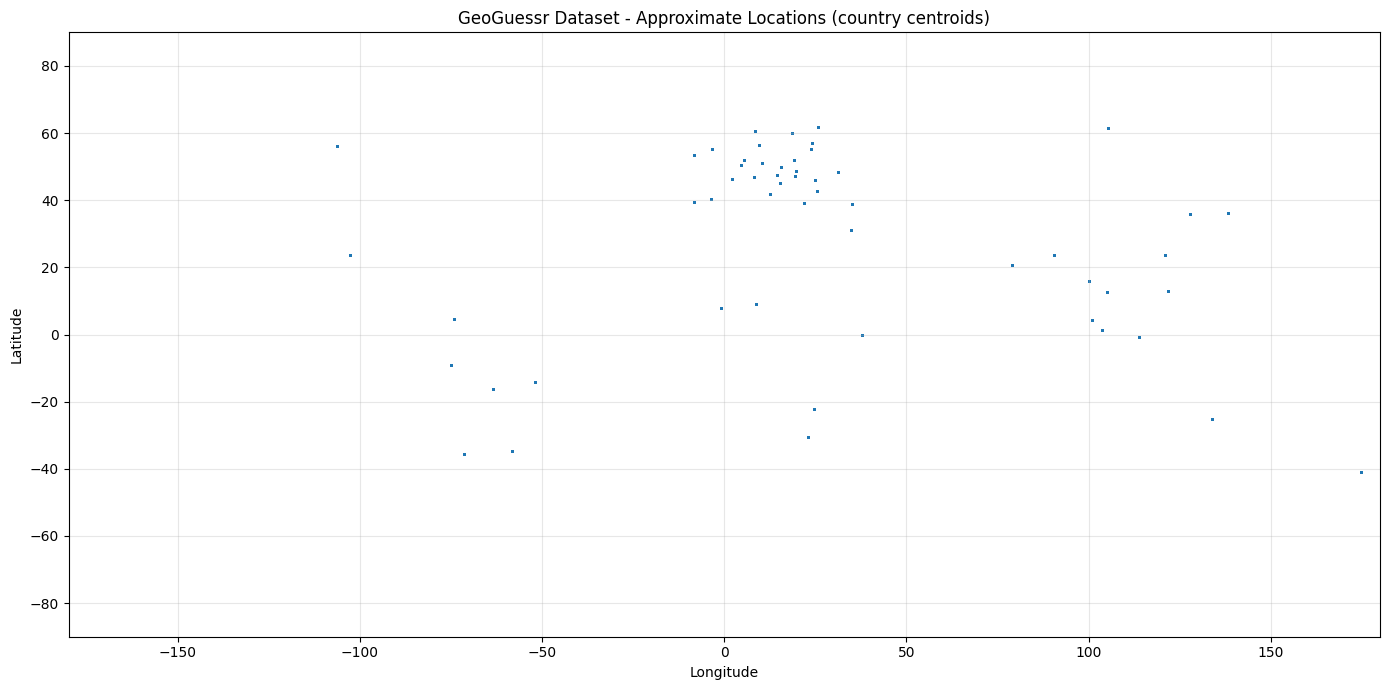

In [9]:
# Plot approximate locations using country centroids
lats = np.array([COUNTRY_CENTROIDS[c][0] for c in countries if c in COUNTRY_CENTROIDS])
lons = np.array([COUNTRY_CENTROIDS[c][1] for c in countries if c in COUNTRY_CENTROIDS])

fig, ax = plt.subplots(1, 1, figsize=(14, 7))
ax.scatter(lons, lats, s=1, alpha=0.3)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('GeoGuessr Dataset - Approximate Locations (country centroids)')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

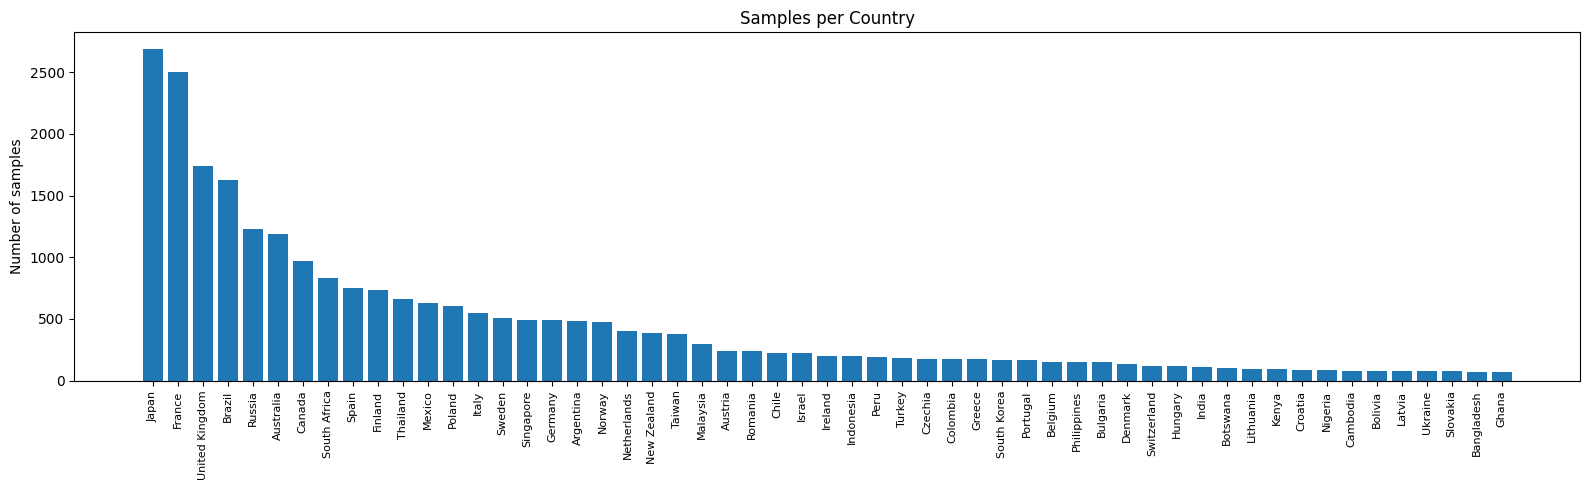

In [10]:
# Country distribution bar chart
sorted_counts = country_counts.most_common()
names = [c for c, _ in sorted_counts]
values = [v for _, v in sorted_counts]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(names)), values)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=8)
ax.set_ylabel('Number of samples')
ax.set_title('Samples per Country')
plt.tight_layout()
plt.show()

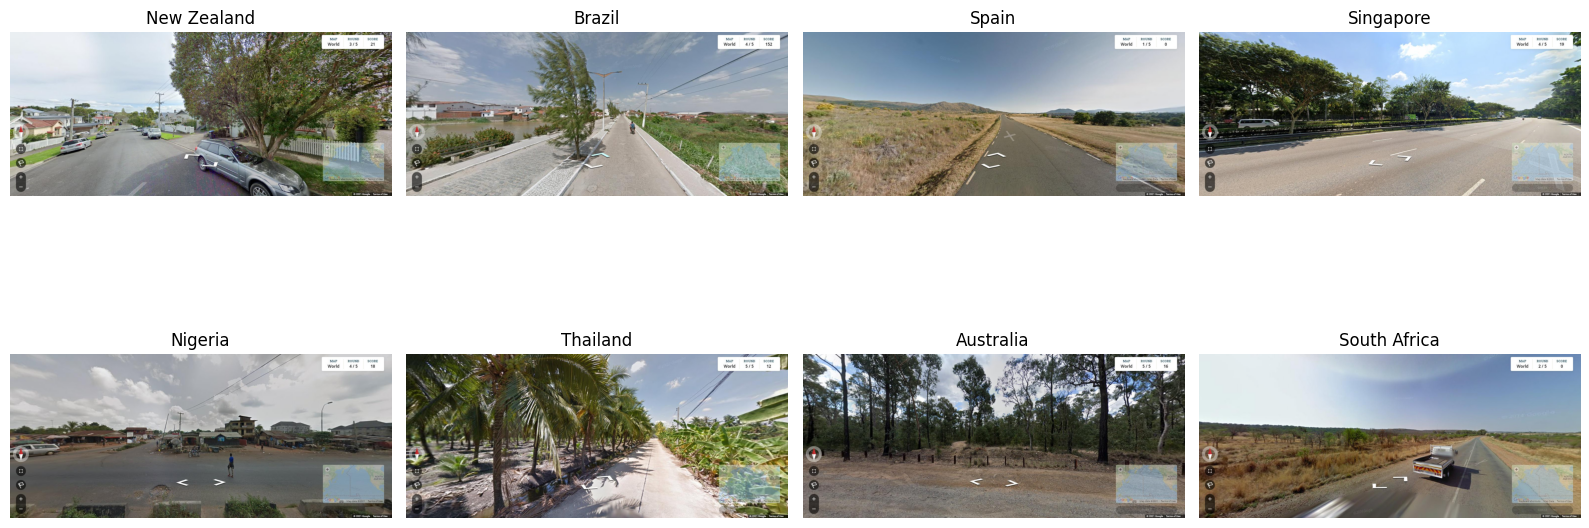

In [11]:
# Show sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(ds))
    item = ds[idx]
    ax.imshow(item['image'])
    ax.set_title(item['label'])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
# Summary stats
print(f'Total samples: {len(ds)}')
print(f'Countries: {len(country_counts)}')
print(f'Samples per country: min={min(values)}, max={max(values)}, mean={np.mean(values):.0f}')

Total samples: 25160
Countries: 55
Samples per country: min=74, max=2688, mean=457
